#PRCP-1015-EquakeDamagePred

My project report in detail

#Importing the dependencies

In [ ]:
import numpy as np
import pandas as pd


Mounting the drive to the colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


The following code is used to look at all the features without any limitation

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

#Basic Understanding of Data

Reading the first CSV file given

In [ ]:
Train_data_labels = pd.read_csv('/content/drive/MyDrive/Datamites_proj_2_EQ/train_labels.csv')
(Train_data_labels.head(5))

,building_id,damage_grade
0,802906,3
1,28830,2
2,94947,3
3,590882,2
4,201944,3


In [ ]:
Train_data_labels_sorted = Train_data_labels.sort_values(by='building_id')
Train_data_labels_sorted.head(70)

,building_id,damage_grade
47748,4,2
212102,8,3
60133,12,3
34181,16,2
25045,17,2
234432,25,1
228351,28,3
33426,31,3
144856,34,2
246970,36,1


In [ ]:
Train_data_labels_sorted.shape

(260601, 2)

Checking the nulls in the 1st csv file given

In [ ]:
Train_data_labels_sorted.isnull().sum()

,0
building_id,0
damage_grade,0


Reading the 2nd csv file given

In [ ]:
Train_data_values = pd.read_csv('/content/drive/MyDrive/Datamites_proj_2_EQ/train_values.csv')
Train_data_values.head(10)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,802906,6,487,12198,2,30,6,5,t,r,n,f,q,t,d,1,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
1,28830,8,900,2812,2,10,8,7,o,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
2,94947,21,363,8973,2,10,5,5,t,r,n,f,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
3,590882,22,418,10694,2,10,6,5,t,r,n,f,x,s,d,0,1,0,0,0,0,1,1,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
4,201944,11,131,1488,3,30,8,9,t,r,n,f,x,s,d,1,0,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
5,333020,8,558,6089,2,10,9,5,t,r,n,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,1,1,0,0,0,0,0,0,0,0,0
6,728451,9,475,12066,2,25,3,4,n,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
7,475515,20,323,12236,2,0,8,6,t,w,q,v,x,s,u,0,0,0,0,0,1,1,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
8,441126,0,757,7219,2,15,8,6,t,r,q,f,q,s,d,0,1,0,0,0,0,1,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
9,989500,26,886,994,1,0,13,4,t,i,n,v,j,s,d,0,0,0,0,0,1,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0


Sorting the 2nd csv file to understand the data

In [ ]:
Train_data_values_sorted = Train_data_values.sort_values(by='building_id')
Train_data_values_sorted.head(70)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
47748,4,30,266,1224,1,25,5,2,t,r,n,f,j,s,d,0,1,0,0,0,0,0,0,0,0,0,v,0,0,0,0,0,0,0,0,0,0,0,0
212102,8,17,409,12182,2,0,13,7,t,r,n,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
60133,12,17,716,7056,2,5,12,6,o,r,q,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
34181,16,4,651,105,2,80,5,4,n,r,n,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
25045,17,3,1387,3909,5,40,5,10,t,r,n,f,q,o,d,0,0,0,0,1,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
234432,25,26,1132,6645,2,0,6,6,t,w,n,f,x,s,d,0,0,0,0,0,0,1,0,0,0,0,a,1,0,0,0,0,0,0,0,0,0,0,0
228351,28,8,1297,9721,2,0,2,6,t,r,n,f,x,s,d,0,1,1,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
33426,31,6,398,4512,2,30,10,5,t,r,n,f,q,t,d,0,1,0,0,0,0,0,0,0,0,0,v,0,1,1,0,0,0,0,0,0,0,0,0
144856,34,7,555,2763,3,40,5,6,t,r,n,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,2,0,0,0,0,0,0,0,0,0,0,0
246970,36,20,508,10459,2,5,7,6,t,w,q,f,q,s,d,0,1,0,0,0,0,0,1,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
Train_data_values_sorted.shape

(260601, 39)

In [ ]:
Train_data_values_sorted.isnull().sum()

,0
building_id,0
geo_level_1_id,0
geo_level_2_id,0
geo_level_3_id,0
count_floors_pre_eq,0
age,0
area_percentage,0
height_percentage,0
land_surface_condition,0
foundation_type,0


Basic understanding of the data:

In [ ]:
Train_data_values.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

Merging the 1st csv on to the 2nd csv(or the main file) after careful consideration

In [ ]:
Final_dataset = Train_data_values.merge(
    Train_data_labels,
    on='building_id',
    how='left'
)
Final_dataset.head(10)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,n,f,q,t,d,1,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,n,f,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,n,f,x,s,d,0,1,0,0,0,0,1,1,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,n,f,x,s,d,1,0,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
5,333020,8,558,6089,2,10,9,5,t,r,n,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,1,1,0,0,0,0,0,0,0,0,0,2
6,728451,9,475,12066,2,25,3,4,n,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
7,475515,20,323,12236,2,0,8,6,t,w,q,v,x,s,u,0,0,0,0,0,1,1,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,1
8,441126,0,757,7219,2,15,8,6,t,r,q,f,q,s,d,0,1,0,0,0,0,1,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
9,989500,26,886,994,1,0,13,4,t,i,n,v,j,s,d,0,0,0,0,0,1,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,1


Just saving the dataset into the drive, for furthur quicker access to the file

In [ ]:
Final_dataset.to_csv(
    '/content/drive/MyDrive/Datamites_proj_2_EQ/Checkpoints_my/Merged_dataset',
    index=False
)


In [ ]:
Final_dataset = pd.read_csv('/content/drive/MyDrive/Datamites_proj_2_EQ/Checkpoints_my/Merged_dataset')
Final_dataset.head(10)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,n,f,q,t,d,1,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,n,f,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,n,f,x,s,d,0,1,0,0,0,0,1,1,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,n,f,x,s,d,1,0,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
5,333020,8,558,6089,2,10,9,5,t,r,n,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,1,1,0,0,0,0,0,0,0,0,0,2
6,728451,9,475,12066,2,25,3,4,n,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
7,475515,20,323,12236,2,0,8,6,t,w,q,v,x,s,u,0,0,0,0,0,1,1,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,1
8,441126,0,757,7219,2,15,8,6,t,r,q,f,q,s,d,0,1,0,0,0,0,1,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
9,989500,26,886,994,1,0,13,4,t,i,n,v,j,s,d,0,0,0,0,0,1,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,1


Understanding the geo_level_* features in the dataset

In [ ]:
print(Final_dataset['geo_level_3_id'].max())
print(Final_dataset['geo_level_3_id'].min())
print(Final_dataset['age'].max())

12567
0
995


## Exploratory data analysis (EDA)

Plotting a box plot to understand if there are any extreme points/outliers in the data..

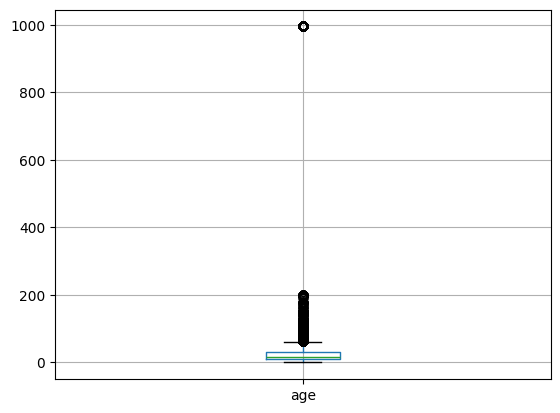

In [ ]:
import matplotlib.pyplot as plt

Final_dataset.boxplot(column=['age'])
plt.show()


**Understanding the numerical columns** through describe

Like max, min, outliers etc etc for all numerical columns

In [ ]:
(Final_dataset.describe())

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
count,2.606010e+05,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,5.256755e+05,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,0.034332,0.018235,0.068154,0.075268,0.254988,0.085011,0.042590,0.015859,0.014985,0.983949,0.111880,0.064378,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119,2.238272
std,3.045450e+05,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,0.182081,0.133800,0.252010,0.263824,0.435855,0.278899,0.201931,0.124932,0.121491,0.418389,0.315219,0.245426,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364,0.611814
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.611900e+05,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,5.257570e+05,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,7.897620e+05,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.052934e+06,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


Inspecting the extreme values that are present in age column because they may represent meaningful structural characteristics rather than noise.

And it turned out to be so many values are same, which usually isnt an outlier specially, for this kind of data, those are no-info.. SO, I need to handle them carefully. Many techniquues are there, The one I implemented(after 2 cells in preprocessing section) is by creating a new column named age_unknown(and given yes or no, based on the extreme point, as yes for the extreme point) - And those extreme point(995) is converted into null, and imputed with the median

In [ ]:
age_records_gt_500 = Final_dataset[Final_dataset['age'] > 500]
(age_records_gt_500)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
386,435557,14,1120,3789,3,995,12,5,t,r,n,f,q,s,d,0,1,0,0,0,0,1,0,0,0,0,v,1,1,1,0,0,0,0,0,0,0,0,0,2
716,597626,26,39,1851,2,995,27,6,t,i,x,v,s,j,d,0,0,0,0,0,1,0,0,0,1,0,v,3,0,0,0,0,0,0,0,0,0,0,0,1
1235,7560,26,1132,9472,2,995,8,5,t,r,q,f,x,s,d,0,1,0,0,0,0,1,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
1398,797271,26,39,1851,2,995,14,6,t,u,n,v,s,t,d,0,0,0,0,0,1,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,1
1635,857371,24,628,10750,2,995,10,5,t,r,n,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
2148,829384,27,181,2607,2,995,4,6,t,r,n,f,q,j,d,0,0,0,0,1,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
2370,132439,14,1120,6614,2,995,10,5,t,r,q,f,q,s,d,0,1,0,0,0,0,1,0,0,0,0,v,1,1,1,0,0,0,0,0,0,0,0,0,3
2851,382719,6,1002,4558,2,995,6,6,t,r,n,f,q,s,d,1,0,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
2869,637115,12,339,9506,2,995,6,4,t,r,n,f,q,s,d,0,1,0,0,0,0,1,1,0,0,0,v,2,0,0,0,0,0,0,0,0,0,0,0,1
2890,773289,6,1002,3931,4,995,25,11,t,r,n,f,q,t,d,1,0,0,0,1,0,0,0,0,0,0,v,5,0,0,0,0,0,0,0,0,0,0,0,2


Understanding of area_percentage column

In [ ]:
area_percentage_above_80 = Final_dataset[Final_dataset['area_percentage'] > 80]
(area_percentage_above_80)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
4790,361707,3,175,6924,8,5,100,26,n,i,x,v,s,s,c,0,0,0,0,0,0,0,0,0,1,0,v,1,1,0,1,0,0,0,0,0,0,0,0,2
10801,962043,8,1414,4224,2,5,85,6,t,r,n,x,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
38062,208991,25,211,2707,2,20,86,4,n,r,n,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
56752,645420,26,39,9897,4,5,86,12,t,i,x,v,s,j,d,0,0,0,0,0,0,0,0,1,0,0,v,0,1,0,1,0,0,0,0,0,0,0,0,1
90924,421198,4,55,1996,2,20,84,5,t,r,q,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
103590,690490,17,1067,9744,2,15,83,6,t,r,n,f,q,s,q,0,1,1,0,0,0,1,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
123327,891753,13,199,2473,2,20,86,4,n,r,n,f,q,s,d,0,1,0,0,0,0,1,1,0,0,0,v,2,0,0,0,0,0,0,0,0,0,0,0,2
127007,220534,6,1082,11745,5,20,96,15,n,i,x,v,s,s,d,0,0,0,0,0,0,0,0,0,1,0,v,0,1,0,1,0,0,0,0,0,0,0,0,2
131606,613670,17,1279,1770,3,25,83,11,n,r,n,x,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
138964,1029545,17,967,4975,3,15,85,15,t,u,x,v,s,s,d,0,0,0,0,0,1,0,0,1,0,0,v,0,1,0,0,0,1,0,0,0,0,0,1,2


Data preprocessing on the age column(Numerical column)

Created age_unknown

In [ ]:
Final_dataset['age_unknown'] = Final_dataset['age'].apply(
    lambda x: 1 if x == 995 else 0
)

Converted 995 into missing values

In [ ]:
import numpy as np

Final_dataset['age'] = Final_dataset['age'].replace(995, np.nan)

Impute missing ages using median

In [ ]:
median_age = Final_dataset['age'].median()

Final_dataset['age'].fillna(median_age, inplace=True)

/tmp/ipykernel_6851/173406159.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Final_dataset['age'].fillna(median_age, inplace=True)


The idea above is implemented since the values in the age column, has lots of 995, in this kind of datasets like building ones, they usually mean they are missing values and not the outliers, so, What i did was to create an extra column with age_unknown as yes/no - And replace the values, with the median, of the data.


Created a new column age_unknown because model can learn:

"Real 25-year-old buildings behave one way"
"Buildings whose age was unknown behave another way"

That extra column age_unknown preserves the information: this value was originally missing

Checking on the age column after preprocessing

In [ ]:
print(Final_dataset['age'].isnull().sum())
print()
print(Final_dataset['age_unknown'].value_counts())


0

age_unknown
0    259211
1      1390
Name: count, dtype: int64


In [ ]:
(Final_dataset['age'].describe())

,age
count,260601.000000
mean,21.307881
std,19.559913
min,0.000000
25%,10.000000
50%,15.000000
75%,30.000000
max,200.000000


Age records checking after the imputation, make sure no extreme values exist.

In [ ]:
age_records_gt_100 = Final_dataset[Final_dataset['age'] > 100]
(age_records_gt_100)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown
324,737045,21,477,4348,3,190.0,6,7,t,r,q,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3,0
419,370360,6,1253,5667,4,105.0,11,9,t,r,n,f,q,s,d,0,0,0,0,0,1,1,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2,0
926,117310,25,50,1097,2,120.0,7,5,t,r,n,f,q,s,a,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2,0
1677,783077,3,1387,4194,4,110.0,4,9,t,r,n,f,q,t,d,1,0,0,0,1,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3,0
1924,249406,3,175,6942,4,120.0,18,10,t,r,n,f,q,o,d,0,0,0,0,1,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2,0
2131,489146,27,181,7055,4,120.0,4,8,t,r,n,f,q,j,d,0,0,0,0,1,0,0,0,0,0,0,v,1,1,0,0,1,0,0,0,0,0,0,0,2,0
2152,190989,27,390,8710,4,110.0,4,10,t,r,n,f,q,o,d,1,1,0,0,1,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2,0
2583,402122,17,1322,6717,3,110.0,8,6,n,r,n,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2,0
3080,421212,17,367,5884,3,120.0,7,7,t,r,n,x,q,t,q,0,1,0,0,0,0,0,0,0,0,0,v,0,0,0,0,0,0,0,0,0,0,0,0,3,0
3589,191081,3,1387,8564,5,105.0,6,10,t,r,n,f,q,j,d,1,0,0,0,1,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3,0


## Data Visualizations part

EDA: Distribution of floors (Histogram)

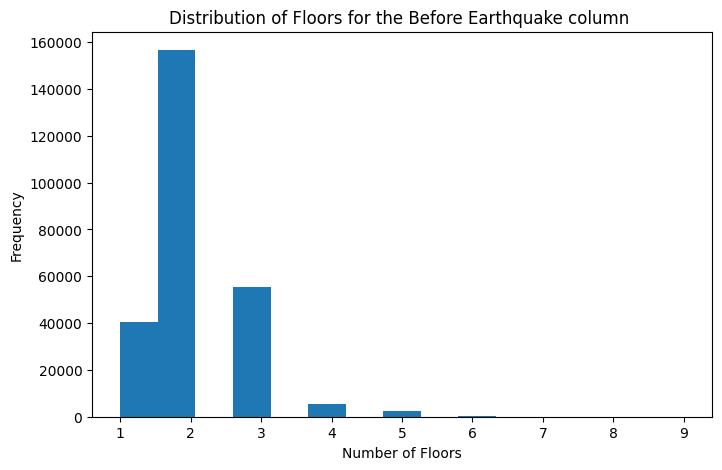

In [ ]:
import matplotlib.pyplot as plt # here v1_Final_dataset is same as Final_dataset

plt.figure(figsize=(8,5))

plt.hist(v1_Final_dataset['count_floors_pre_eq'], bins=15)

plt.title('Distribution of Floors for the Before Earthquake column ')
plt.xlabel('Number of Floors')
plt.ylabel('Frequency')

plt.show()

Count plot:

This shows how many samples belong to each damage class. As we can see (inference from the plot) majority of building were hit at Grade 2 level, followed by Grade 3, then Grade 1

/tmp/ipykernel_970/3645144647.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


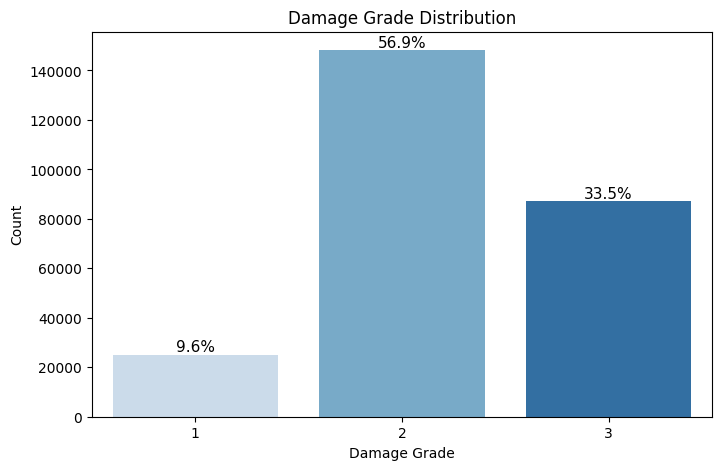

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='damage_grade',
    data=v1_Final_dataset,
    palette='Blues'
)

# Total rows
total = len(v1_Final_dataset)

# Add percentage labels
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total

    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width()/2., count),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title('Damage Grade Distribution')
plt.xlabel('Damage Grade')
plt.ylabel('Count')

plt.show()

Visualization plot: Damage Grade Distribution across Age Groups

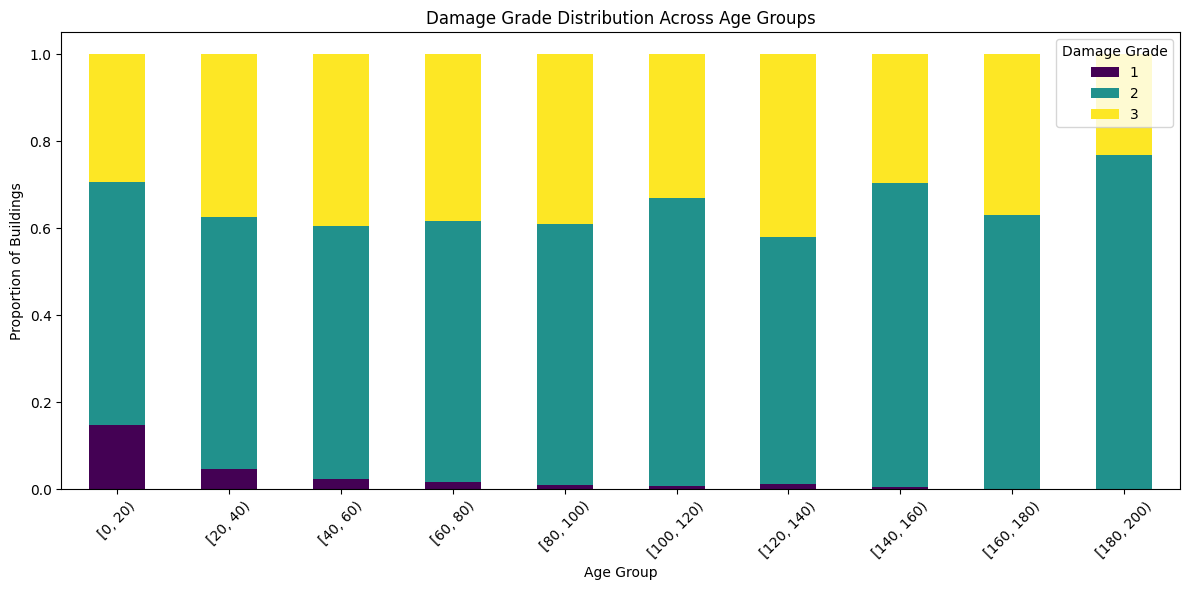

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = v1_Final_dataset.copy()

#  Ensure age is numeric
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Drop missing age values (important for clean bins)
df = df.dropna(subset=['age'])

# Create bins (0–20–40–... up to max age)
max_age = int(df['age'].max()) + 20
bins = range(0, max_age, 20)

#  Create age groups
df['age_group'] = pd.cut(df['age'], bins=bins, right=False)

# Build proportion table (very important for fair comparison)
age_damage = pd.crosstab(
    df['age_group'],
    df['damage_grade'],
    normalize='index'
)

# Final step : Plot stacked bar chart
age_damage.plot(kind='bar', stacked=True, figsize=(12,6), colormap='viridis')

plt.title('Damage Grade Distribution Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Proportion of Buildings')
plt.xticks(rotation=45)
plt.legend(title='Damage Grade')
plt.tight_layout()
plt.show()

Inference : Here, as we can clearly see, as the building age kept on increasing, the Damage grade 1, kept on decreasing. Which in turn they were affected at the higher range, either grade 2 or grade 3. So, age column does plays an very important role

Data visualization: Area_percentage distribution

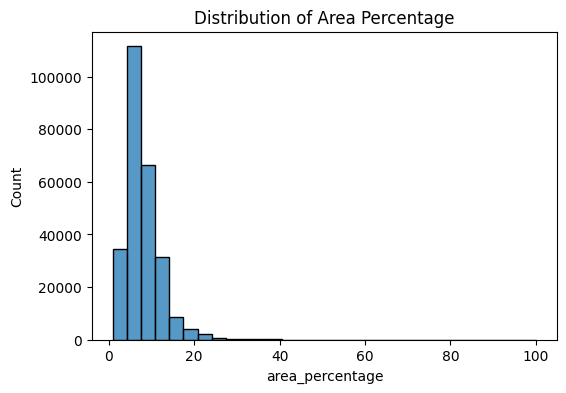

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.histplot(v1_Final_dataset['area_percentage'], bins=30)
plt.title('Distribution of Area Percentage')
plt.show()

Data visualization : Distribution of Height percentage

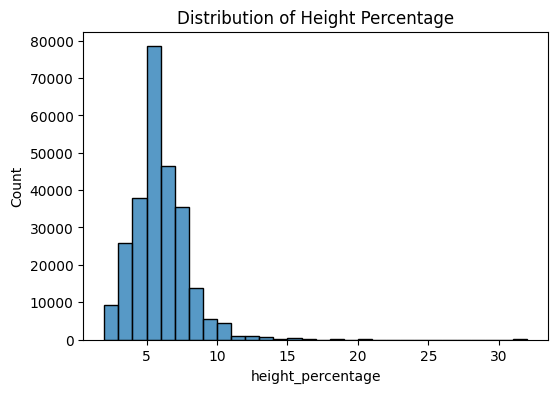

In [ ]:

plt.figure(figsize=(6,4))
sns.histplot(v1_Final_dataset['height_percentage'], bins=30)
plt.title('Distribution of Height Percentage')
plt.show()

From the height and area distributions, we can say, Most of data falls in the range of 0 to 20 for area_percentage, and 0 to 15 for height percentage. And the data is pretty much skewed by visually looking at it.

Visualization plot: Distribution of count_families(number of families)



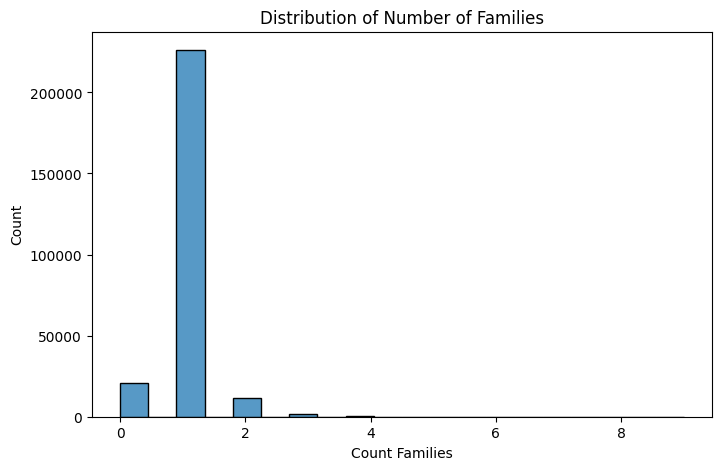

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    v1_Final_dataset['count_families'],
    bins=20,

)

plt.title('Distribution of Number of Families')
plt.xlabel('Count Families')
plt.show()

Inference:

count_families shows a left-skewed distribution, indicating that most buildings contain a small number of families while fewer buildings accommodate larger numbers. The higher values may represent genuine larger residential structures rather than anomalies; therefore no treatment is applied at this stage."

Visualization of data: Damage Distribution by Family Count

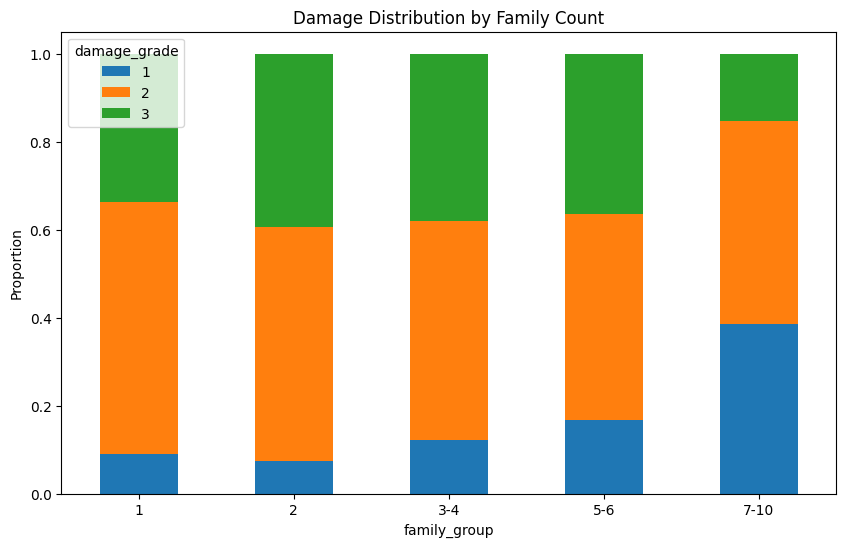

In [ ]:
import pandas as pd

df = v1_Final_dataset.copy()

bins = [0,1,2,4,6,10,20]
labels = ['1','2','3-4','5-6','7-10','10+']

df['family_group'] = pd.cut(
    df['count_families'],
    bins=bins,
    labels=labels
)

family_damage = pd.crosstab(
    df['family_group'],
    df['damage_grade'],
    normalize='index'
)

family_damage.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Damage Distribution by Family Count')
plt.ylabel('Proportion')
plt.xticks(rotation=0)

plt.show()

Inference from the plot : For building with more families, they got impacted with less(grade 1), which is a good thing

## Checking whether there are any duplicate rows

In [ ]:
# Show all duplicate rows (excluding the first occurrence by default)
duplicates = v1_Final_dataset[v1_Final_dataset.duplicated()]
print(duplicates)


Empty DataFrame
Columns: [building_id, geo_level_1_id, geo_level_2_id, geo_level_3_id, count_floors_pre_eq, age, area_percentage, height_percentage, land_surface_condition, foundation_type, roof_type, ground_floor_type, other_floor_type, position, plan_configuration, has_superstructure_adobe_mud, has_superstructure_mud_mortar_stone, has_superstructure_stone_flag, has_superstructure_cement_mortar_stone, has_superstructure_mud_mortar_brick, has_superstructure_cement_mortar_brick, has_superstructure_timber, has_superstructure_bamboo, has_superstructure_rc_non_engineered, has_superstructure_rc_engineered, has_superstructure_other, legal_ownership_status, count_families, has_secondary_use, has_secondary_use_agriculture, has_secondary_use_hotel, has_secondary_use_rental, has_secondary_use_institution, has_secondary_use_school, has_secondary_use_industry, has_secondary_use_health_post, has_secondary_use_gov_office, has_secondary_use_use_police, has_secondary_use_other, damage_grade, age_unkno

Inference: There are no duplicate rows

**Checking/understanding the categorical columns in the dataset**



In [ ]:
categorical_cols = Final_dataset.select_dtypes(include=['object', 'category']).columns


for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(Final_dataset[col].value_counts())



--- land_surface_condition ---
land_surface_condition
t    216757
n     35528
o      8316
Name: count, dtype: int64

--- foundation_type ---
foundation_type
r    219196
w     15118
u     14260
i     10579
h      1448
Name: count, dtype: int64

--- roof_type ---
roof_type
n    182842
q     61576
x     16183
Name: count, dtype: int64

--- ground_floor_type ---
ground_floor_type
f    209619
x     24877
v     24593
z      1004
m       508
Name: count, dtype: int64

--- other_floor_type ---
other_floor_type
q    165282
x     43448
j     39843
s     12028
Name: count, dtype: int64

--- position ---
position
s    202090
t     42896
j     13282
o      2333
Name: count, dtype: int64

--- plan_configuration ---
plan_configuration
d    250072
q      5692
u      3649
s       346
c       325
a       252
o       159
m        46
n        38
f        22
Name: count, dtype: int64

--- legal_ownership_status ---
legal_ownership_status
v    250939
a      5512
w      2677
r      1473
Name: count, dtype: 

In [ ]:
Final_dataset.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown
0,802906,6,487,12198,2,30.0,6,5,t,r,n,f,q,t,d,1,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3,0
1,28830,8,900,2812,2,10.0,8,7,o,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2,0
2,94947,21,363,8973,2,10.0,5,5,t,r,n,f,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3,0
3,590882,22,418,10694,2,10.0,6,5,t,r,n,f,x,s,d,0,1,0,0,0,0,1,1,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2,0
4,201944,11,131,1488,3,30.0,8,9,t,r,n,f,x,s,d,1,0,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3,0


Saving the dataset, for quicker access later on

In [ ]:
Final_dataset.to_csv(
    '/content/drive/MyDrive/Datamites_proj_2_EQ/Checkpoints_my/v1_age_preprocessed',
    index=False
)


Loading/Reading the dataset

In [ ]:
v1_Final_dataset = pd.read_csv('/content/drive/MyDrive/Datamites_proj_2_EQ/Checkpoints_my/v1_age_preprocessed')
v1_Final_dataset.head(5)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown
0,802906,6,487,12198,2,30.0,6,5,t,r,n,f,q,t,d,1,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3,0
1,28830,8,900,2812,2,10.0,8,7,o,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2,0
2,94947,21,363,8973,2,10.0,5,5,t,r,n,f,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3,0
3,590882,22,418,10694,2,10.0,6,5,t,r,n,f,x,s,d,0,1,0,0,0,0,1,1,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2,0
4,201944,11,131,1488,3,30.0,8,9,t,r,n,f,x,s,d,1,0,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3,0


In [ ]:
v1_Final_dataset.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown
0,802906,6,487,12198,2,30.0,6,5,t,r,n,f,q,t,d,1,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3,0
1,28830,8,900,2812,2,10.0,8,7,o,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2,0
2,94947,21,363,8973,2,10.0,5,5,t,r,n,f,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3,0
3,590882,22,418,10694,2,10.0,6,5,t,r,n,f,x,s,d,0,1,0,0,0,0,1,1,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2,0
4,201944,11,131,1488,3,30.0,8,9,t,r,n,f,x,s,d,1,0,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3,0


Visualization plot: Damage Grade Distribution for different foundatation type

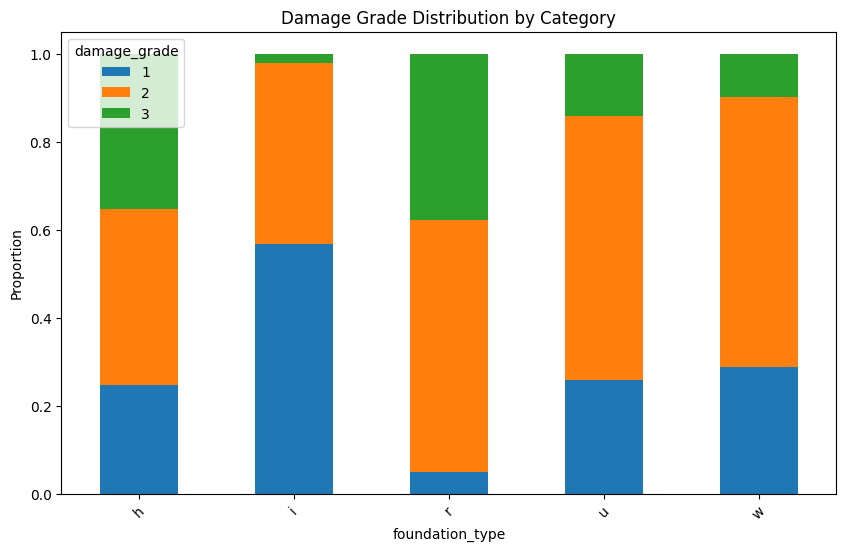

In [ ]:
df = v1_Final_dataset.copy()
import matplotlib.pyplot as plt
import seaborn as sns
cat_damage = pd.crosstab(
    df['foundation_type'],
    df['damage_grade'],
    normalize='index'
)

cat_damage.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Damage Grade Distribution by Category')
plt.ylabel('Proportion')
plt.xticks(rotation=45)

plt.show()

For this plot, we can conclude when foundation_type is "i", it has strong resistance to larger grade damage, compared to other categories of the foundation_type. And foundation_type - "r" has the least resistance to any damage grade

Visualization plot: Damage Grade Distribution for different ground_floor_type

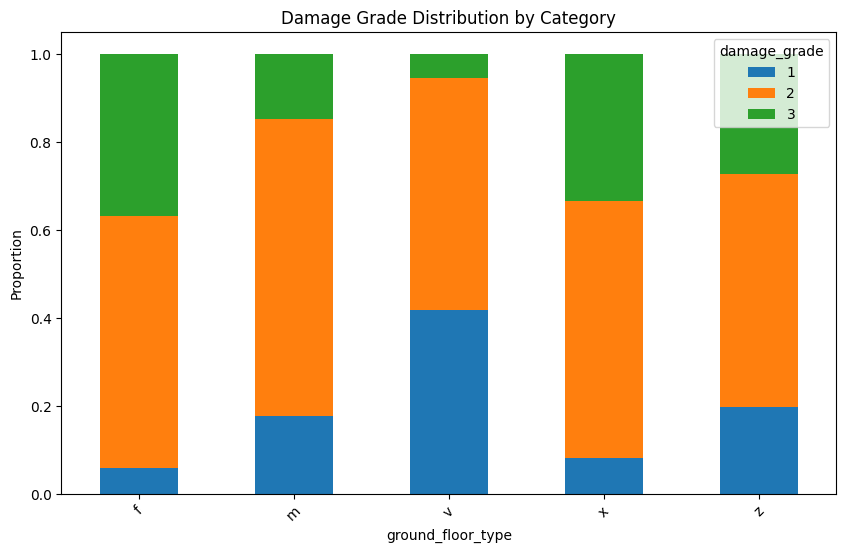

In [ ]:

df = v1_Final_dataset.copy()
cat_damage = pd.crosstab(
    df['ground_floor_type'],
    df['damage_grade'],
    normalize='index'
)

cat_damage.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Damage Grade Distribution by Category')
plt.ylabel('Proportion')
plt.xticks(rotation=45)

plt.show()

Inference: From the plot, we can conclude; When it comes to the ground_floor_type, the "v" category has less impact from the earthquake and was most resistant, where as , when the floor_type with f and x took a bit higher grade impact, compared to others.

Null values check: Checking whether if there are any null values in each column

In [ ]:
v1_Final_dataset.isnull().sum()

,0
building_id,0
geo_level_1_id,0
geo_level_2_id,0
geo_level_3_id,0
count_floors_pre_eq,0
age,0
area_percentage,0
height_percentage,0
land_surface_condition,0
foundation_type,0


Inference: As, we can see; There are no nulls, in any columns

**Data Preprocessing for categorical columns**

In [ ]:
v1_Final_dataset.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown
0,802906,6,487,12198,2,30.0,6,5,t,r,n,f,q,t,d,1,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3,0
1,28830,8,900,2812,2,10.0,8,7,o,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2,0
2,94947,21,363,8973,2,10.0,5,5,t,r,n,f,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3,0
3,590882,22,418,10694,2,10.0,6,5,t,r,n,f,x,s,d,0,1,0,0,0,0,1,1,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2,0
4,201944,11,131,1488,3,30.0,8,9,t,r,n,f,x,s,d,1,0,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3,0


First and Foremost, Understanding the categorical columns

In [ ]:
categorical_cols_1 = v1_Final_dataset.select_dtypes(include=['object', 'category']).columns


for col in categorical_cols_1:
    print(f"\n--- {col} ---")
    print(v1_Final_dataset[col].value_counts())



--- land_surface_condition ---
land_surface_condition
t    216757
n     35528
o      8316
Name: count, dtype: int64

--- foundation_type ---
foundation_type
r    219196
w     15118
u     14260
i     10579
h      1448
Name: count, dtype: int64

--- roof_type ---
roof_type
n    182842
q     61576
x     16183
Name: count, dtype: int64

--- ground_floor_type ---
ground_floor_type
f    209619
x     24877
v     24593
z      1004
m       508
Name: count, dtype: int64

--- other_floor_type ---
other_floor_type
q    165282
x     43448
j     39843
s     12028
Name: count, dtype: int64

--- position ---
position
s    202090
t     42896
j     13282
o      2333
Name: count, dtype: int64

--- plan_configuration ---
plan_configuration
d    250072
q      5692
u      3649
s       346
c       325
a       252
o       159
m        46
n        38
f        22
Name: count, dtype: int64

--- legal_ownership_status ---
legal_ownership_status
v    250939
a      5512
w      2677
r      1473
Name: count, dtype: 

Choosen one hot encoding for 7 categorical columnns out of 8 columns because, there are like 3 to 5 classes in each column, and it is still in low cardinality zone, So, I have choosen One hot encoding..

And also there is no hierarchy in the classes for each categorical column

In [ ]:
import pandas as pd

categorical_cols = [
    'land_surface_condition',
    'foundation_type',
    'roof_type',
    'ground_floor_type',
    'other_floor_type', 'position',
    'legal_ownership_status'
]

v1_Final_dataset = pd.get_dummies(
    v1_Final_dataset,
    columns=categorical_cols,
    drop_first=True
)

Understanding final shape of the dataset

In [ ]:
v1_Final_dataset.shape

(260601, 55)

Saving the dataset, after one hot encoding for furthur sessions:

In [ ]:
v1_Final_dataset.to_csv(
    '/content/drive/MyDrive/Datamites_proj_2_EQ/Checkpoints_my/v2_category_encoding',
    index=False
)


Reading the encoded dataset.

In [ ]:
v2_Final_dataset = pd.read_csv('/content/drive/MyDrive/Datamites_proj_2_EQ/Checkpoints_my/v2_category_encoding')
v2_Final_dataset.head(5)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w
0,802906,6,487,12198,2,30.0,6,5,d,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False
1,28830,8,900,2812,2,10.0,8,7,d,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,True,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,True,False
2,94947,21,363,8973,2,10.0,5,5,d,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False
3,590882,22,418,10694,2,10.0,6,5,d,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False
4,201944,11,131,1488,3,30.0,8,9,d,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False


Since we've already run the one-hot encoding, the original categorical columns are gone and the new dummy columns already exist as True/False.

And I converted all boolean columns in-place to 0/1. Through the code in below cell

In [ ]:
bool_cols = v2_Final_dataset.select_dtypes(include='bool').columns

v2_Final_dataset[bool_cols] = v1_Final_dataset[bool_cols].astype(int)
v2_Final_dataset.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w
0,802906,6,487,12198,2,30.0,6,5,d,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0
1,28830,8,900,2812,2,10.0,8,7,d,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0
2,94947,21,363,8973,2,10.0,5,5,d,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0
3,590882,22,418,10694,2,10.0,6,5,d,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0
4,201944,11,131,1488,3,30.0,8,9,d,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0


Saving the file for easier and quicker access

In [ ]:
v2_Final_dataset.to_csv(
    '/content/drive/MyDrive/Datamites_proj_2_EQ/Checkpoints_my/v2_category_encoding_exception',
    index=False
)


In [ ]:
v3_Final_dataset = pd.read_csv('/content/drive/MyDrive/Datamites_proj_2_EQ/Checkpoints_my/v2_category_encoding_exception')
v3_Final_dataset.head(5)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w
0,802906,6,487,12198,2,30.0,6,5,d,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0
1,28830,8,900,2812,2,10.0,8,7,d,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0
2,94947,21,363,8973,2,10.0,5,5,d,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0
3,590882,22,418,10694,2,10.0,6,5,d,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0
4,201944,11,131,1488,3,30.0,8,9,d,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0


My plan from here,

since plan_configuration has more than 10 classes, for a baseline point of view. I would just go for one hot for the plan_configuration too. as a baseline, then probably a different encoding one (I believe target encoding can also be good choice). But one hot encoding isnt bad either..

And having 60 to 70 columns is completely okay for many models

In [ ]:
v3_Final_dataset = pd.get_dummies(
    v3_Final_dataset,
    columns=['plan_configuration'],
    drop_first=True,
    dtype=int
)

In [ ]:
v3_Final_dataset.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u
0,802906,6,487,12198,2,30.0,6,5,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
1,28830,8,900,2812,2,10.0,8,7,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
2,94947,21,363,8973,2,10.0,5,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
3,590882,22,418,10694,2,10.0,6,5,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
4,201944,11,131,1488,3,30.0,8,9,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0


In [ ]:
v3_Final_dataset.shape

(260601, 63)

And the total column count resulted after completely converting the data into numerical(before modeling) is 63 columns

Understanding the data, after encoding, to make sure everything is in place

In [ ]:
v3_Final_dataset.describe()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u
count,2.606010e+05,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.00000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,5.256755e+05,13.900353,701.074685,6257.876148,2.129723,21.307881,8.018051,5.434365,0.088645,0.761935,0.034332,0.018235,0.068154,0.075268,0.254988,0.085011,0.042590,0.015859,0.014985,0.983949,0.111880,0.064378,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119,2.238272,0.005334,0.031911,0.831758,0.040595,0.841117,0.054720,0.058012,0.236285,0.062099,0.001949,0.094370,0.09546,0.003853,0.634234,0.046155,0.166722,0.008952,0.775477,0.164604,0.005652,0.962924,0.010272,0.001247,0.959597,0.000084,0.000177,0.000146,0.000610,0.021842,0.001328,0.014002
std,3.045450e+05,8.033617,412.710734,3646.369645,0.727665,19.559913,4.392231,1.918418,0.284231,0.425900,0.182081,0.133800,0.252010,0.263824,0.435855,0.278899,0.201931,0.124932,0.121491,0.418389,0.315219,0.245426,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364,0.611814,0.072838,0.175763,0.374082,0.197350,0.365567,0.227433,0.233767,0.424800,0.241335,0.044108,0.292344,0.29385,0.061950,0.481645,0.209821,0.372728,0.094193,0.417269,0.370824,0.074969,0.188948,0.100831,0.035293,0.196902,0.009188,0.013285,0.012075,0.024693,0.146167,0.036413,0.117500
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00

Checking if everything is in numerical format/ numerical datatype, before modeling

In [ ]:
v3_Final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 63 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   building_id                             260601 non-null  int64  
 1   geo_level_1_id                          260601 non-null  int64  
 2   geo_level_2_id                          260601 non-null  int64  
 3   geo_level_3_id                          260601 non-null  int64  
 4   count_floors_pre_eq                     260601 non-null  int64  
 5   age                                     260601 non-null  float64
 6   area_percentage                         260601 non-null  int64  
 7   height_percentage                       260601 non-null  int64  
 8   has_superstructure_adobe_mud            260601 non-null  int64  
 9   has_superstructure_mud_mortar_stone     260601 non-null  int64  
 10  has_superstructure_stone_flag           2606

Saving the completely encoded data set

In [ ]:
v3_Final_dataset.to_csv(
    '/content/drive/MyDrive/Datamites_proj_2_EQ/Checkpoints_my/v3_all_category_to_numerical',
    index=False
)


In [ ]:
v4_Final_dataset = pd.read_csv('/content/drive/MyDrive/Datamites_proj_2_EQ/Checkpoints_my/v3_all_category_to_numerical')
v4_Final_dataset.head(5)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u
0,802906,6,487,12198,2,30.0,6,5,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
1,28830,8,900,2812,2,10.0,8,7,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
2,94947,21,363,8973,2,10.0,5,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
3,590882,22,418,10694,2,10.0,6,5,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
4,201944,11,131,1488,3,30.0,8,9,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0


Since there are columns, with larger values, I am planning to reduce the magnitude, So, that model will understand easily. One way is to use transformations. To do that I need check the distributions, before applying any log/power etc transformation.

So, below are the visualizations and conclusions what can be applied.

**KDE distribution for age column**

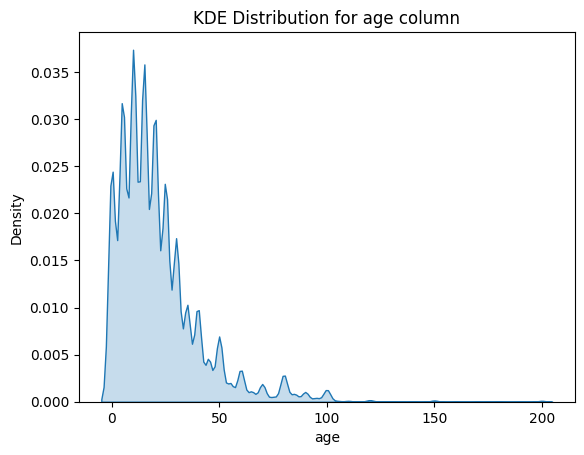

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=v4_Final_dataset, x='age', fill=True)

plt.title('KDE Distribution for age column')
plt.show()

Age is right-skewed.


Widely recommanded transformation: Log transform


Reason: compresses large values, reduces skewness.

**KDE distribution for area_percentage column**

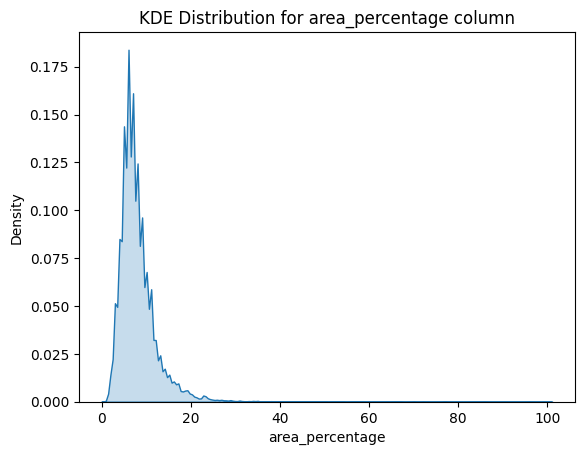

In [ ]:
sns.kdeplot(data=v4_Final_dataset, x='area_percentage', fill=True)

plt.title('KDE Distribution for area_percentage column')
plt.show()

Area_percentage is  right-skewed.


Widely recommanded transformation here also is Log transform


Reason: compresses large values, reduces skewness.

**KDE distribution for height_percentage column**

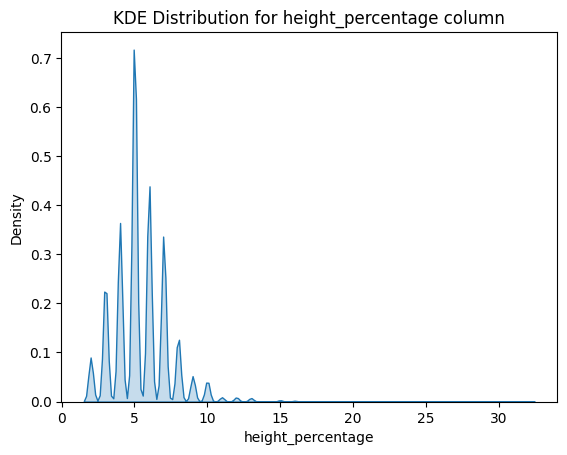

In [ ]:
sns.kdeplot(data=v4_Final_dataset, x='height_percentage', fill=True)

plt.title('KDE Distribution for height_percentage column')
plt.show()

Moderate range for the height_percentage column.

By Checking the shape of the plot. It comes between Fairly distributed and mild skew

Recommanded - leave it as it is not heavily skewed.

**KDE distribution for count_floors_pre_eq column**

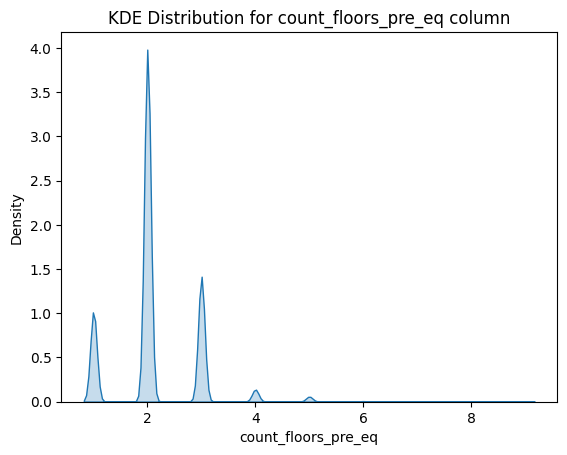

In [ ]:
sns.kdeplot(data=v4_Final_dataset, x='count_floors_pre_eq', fill=True)

plt.title('KDE Distribution for count_floors_pre_eq column')
plt.show()

Inference

For count_floors_pre_eq - tiny range


already interpretable


transformation likely adds little, so no transformation required

**KDE Distribution for count_families column**

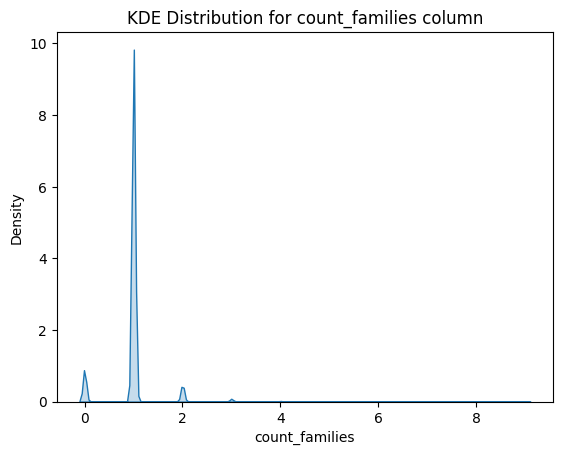

In [ ]:
sns.kdeplot(data=v4_Final_dataset, x='count_families', fill=True)

plt.title('KDE Distribution for count_families column')
plt.show()

Inferences: For the count_families column - values are meaningful..

Counts and range is tiny: So, I will keep them as it is(no transformation)s

Here ends the understanding of the plots, The main reason, I understood few only that is 5 columns plots, since those will be needed for transformation/scaling, and also based on domain knowledge I need to choose those columns, rest all are irrelavent, since most of them are binary or just count, which we did earlier itself

## Transformation part from here on

Because these columns contains 0, using: log(1+x)

instead of plain log(x).

This avoids problems like: log(0) → undefined

**Applying log transformation on the age and area_percentage columns**

In [ ]:
import numpy as np

v4_Final_dataset['age'] = np.log1p(v4_Final_dataset['age'])

v4_Final_dataset['area_percentage'] = np.log1p(
    v4_Final_dataset['area_percentage']
)

In [ ]:
v4_before_transform = v3_Final_dataset.copy()

Replotting the histograms of these two columns and comparing:

Before transformation vs after transformation for age and area_percentage columns

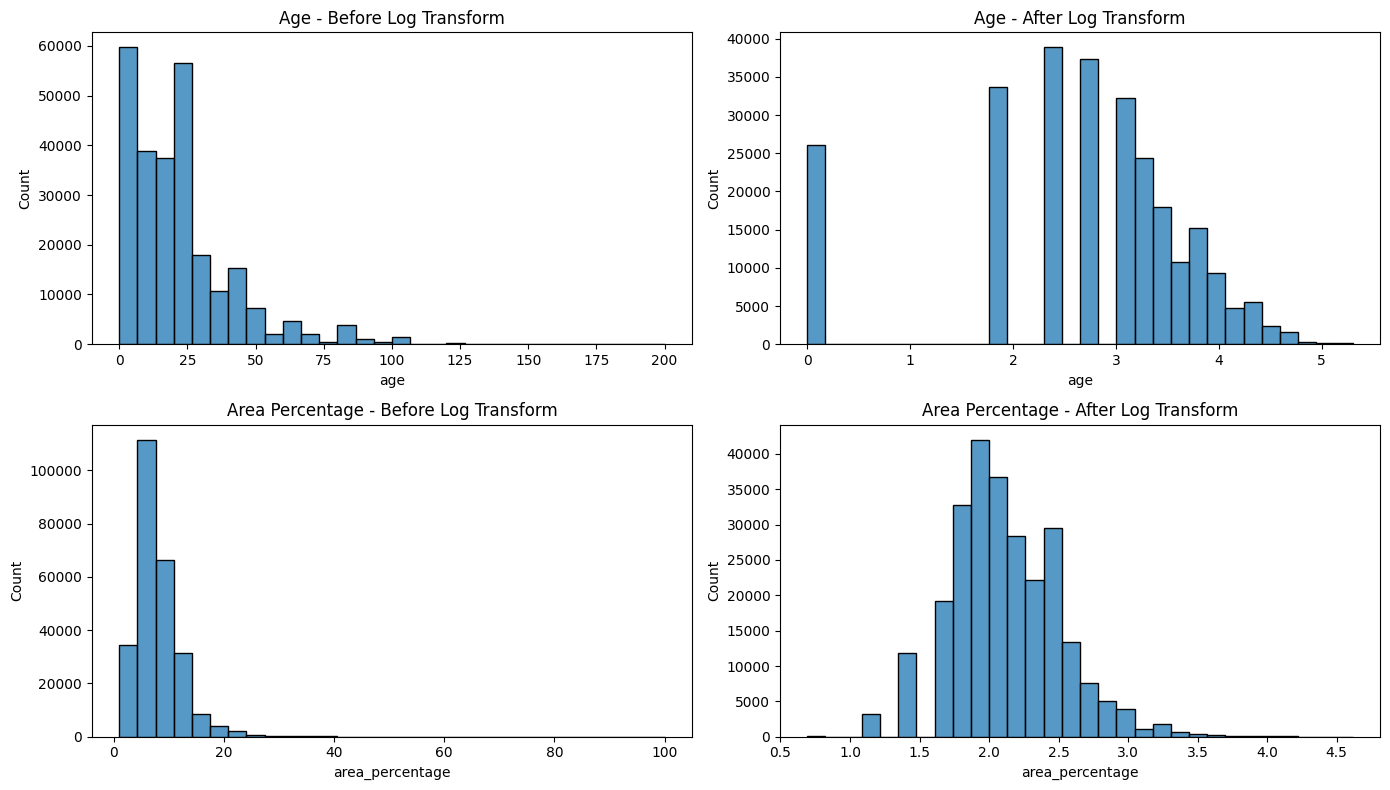

In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(14,8))

# Age: Before
sns.histplot(
    v4_before_transform['age'],
    bins=30,

    ax=axes[0,0]
)
axes[0,0].set_title('Age - Before Log Transform')

# Age: After
sns.histplot(
    v4_Final_dataset['age'],
    bins=30,

    ax=axes[0,1]
)
axes[0,1].set_title('Age - After Log Transform')

# Area: Before
sns.histplot(
    v4_before_transform['area_percentage'],
    bins=30,

    ax=axes[1,0]
)
axes[1,0].set_title('Area Percentage - Before Log Transform')

# Area: After
sns.histplot(
    v4_Final_dataset['area_percentage'],
    bins=30,

    ax=axes[1,1]
)
axes[1,1].set_title('Area Percentage - After Log Transform')

plt.tight_layout()
plt.show()

Reading the data to make sure, everything is alright after transformations

In [ ]:
v4_Final_dataset.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u
0,802906,6,487,12198,2,3.433987,1.945910,5,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
1,28830,8,900,2812,2,2.397895,2.197225,7,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
2,94947,21,363,8973,2,2.397895,1.791759,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
3,590882,22,418,10694,2,2.397895,1.945910,5,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
4,201944,11,131,1488,3,3.433987,2.197225,9,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0


Saving the data, for quicker access, later on

In [ ]:
v4_Final_dataset.to_csv(
    '/content/drive/MyDrive/Datamites_proj_2_EQ/Checkpoints_my/v4_transformed_data',
    index=False
)


In [ ]:
v4_transformed_dataset = pd.read_csv('/content/drive/MyDrive/Datamites_proj_2_EQ/Checkpoints_my/v4_transformed_data')
v4_transformed_dataset.head(5)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u
0,802906,6,487,12198,2,3.433987,1.945910,5,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
1,28830,8,900,2812,2,2.397895,2.197225,7,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
2,94947,21,363,8973,2,2.397895,1.791759,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
3,590882,22,418,10694,2,2.397895,1.945910,5,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
4,201944,11,131,1488,3,3.433987,2.197225,9,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0


In [ ]:
v4_transformed_dataset.head(50)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u
0,802906,6,487,12198,2,3.433987,1.945910,5,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
1,28830,8,900,2812,2,2.397895,2.197225,7,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
2,94947,21,363,8973,2,2.397895,1.791759,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
3,590882,22,418,10694,2,2.397895,1.945910,5,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
4,201944,11,131,1488,3,3.433987,2.197225,9,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
5,333020,8,558,6089,2,2.397895,2.302585,5,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
6,728451,9,475,12066,2,3.258097,1.386294,4,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
7,475515,20,323,12236,2,0.000000,2.197225,6,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1
8,441126,0,757,7219,2,2.772589,2.197225,6,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
9,989500,26,886,994,1,0.000000,2.639057,4,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0


Main columns, the geo_level_1, the geo_level_2, the geo_level_3 needs to be transformed too, because they are in range from 0 to ~ 15,000. Which are not the values, they are to be read as coordinates/ to understand location or region identifiers.

In [ ]:
print(v4_transformed_dataset['geo_level_3_id'].nunique())
print(v4_transformed_dataset['geo_level_2_id'].nunique())
print(v4_transformed_dataset['geo_level_1_id'].nunique()) # understanding the unique values for those 3 columns

11595
1414
31


In [ ]:
v4_transformed_dataset.shape

(260601, 63)

We have:

geo_level_1_id → ~30 unique
geo_level_2_id → ~1400 unique
geo_level_3_id → ~11,000 unique

That pattern tells you something important:

These are hierarchical location identifiers with increasing granularity.

The quite common practise is Frequency encoding

**Frequency encoding replaces:**

“Which region is this?”

with:

“How common is this region in the dataset?”

So: captures urban vs rural density effects
avoids huge dimensional explosion (unlike one-hot)
avoids fake numeric ordering (unlike label encoding)

Below is the Frequency encoding for the geo_level_* columns (Since they are super high cardinality features)

In [ ]:
geo_cols = [
    'geo_level_1_id',
    'geo_level_2_id',
    'geo_level_3_id'
]

for col in geo_cols:
    freq_map = v4_transformed_dataset[col].value_counts() / len(v4_transformed_dataset)
    v4_transformed_dataset[col] = v4_transformed_dataset[col].map(freq_map)

In [ ]:
v4_transformed_dataset.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u
0,802906,0.093557,0.001036,0.000142,2,3.433987,1.945910,5,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
1,28830,0.073215,0.000764,0.000061,2,2.397895,2.197225,7,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
2,94947,0.057133,0.006754,0.000522,2,2.397895,1.791759,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
3,590882,0.023991,0.000787,0.000119,2,2.397895,1.945910,5,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
4,201944,0.031542,0.003983,0.000468,3,3.433987,2.197225,9,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0


Saving the encoded data, for later quicker access

In [ ]:
v4_transformed_dataset.to_csv(
    '/content/drive/MyDrive/Datamites_proj_2_EQ/Checkpoints_my/v5_transformed_data',
    index=False
)

In [ ]:


v5_transformed_dataset = pd.read_csv('/content/drive/MyDrive/Datamites_proj_2_EQ/Checkpoints_my/v5_transformed_data')
v5_transformed_dataset.head(5)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u
0,802906,0.093557,0.001036,0.000142,2,3.433987,1.945910,5,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
1,28830,0.073215,0.000764,0.000061,2,2.397895,2.197225,7,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
2,94947,0.057133,0.006754,0.000522,2,2.397895,1.791759,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
3,590882,0.023991,0.000787,0.000119,2,2.397895,1.945910,5,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
4,201944,0.031542,0.003983,0.000468,3,3.433987,2.197225,9,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0


**Proceeding to next step:**


**Train test split:**

In [ ]:
from sklearn.model_selection import train_test_split

X = v5_transformed_dataset.drop(columns=['damage_grade', 'building_id'])
y = v5_transformed_dataset['damage_grade']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=9,
    stratify=y
)

Stratification is done which ensures

Both train and test maintain:

same class proportions,
realistic distribution,
fair evaluation.

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(195450, 61)
(65151, 61)
(195450,)
(65151,)


##Model Training

**Random Forest baseline**

Why did I Choose Random Forest classifier as it resists overfitting, and can produce feature importance results for us, and also its immune to outliers, and works well on non - linear data

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=20,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, n_jobs=-1, random_state=42)

Rather than going with default setting

These choices for the parameters are considered by taking following points into the idea:

- prevent overfitting (very important for this dataset)

- handle imbalance better


- make results more stable

**Model prediction & evaluation part for random forest**

In [ ]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# --------------------
# Predictions
# --------------------
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# --------------------
# Macro F1 Scores
# --------------------
train_f1 = f1_score(y_train, y_train_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Train Macro F1:", train_f1)
print("Test Macro F1:", test_f1)

# --------------------
# Classification Report (Test)
# --------------------
print("\nClassification Report (Test Data):\n")
print(classification_report(y_test, y_test_pred))

# --------------------
# Confusion Matrix
# --------------------
print("\nConfusion Matrix (Test Data):\n")
print(confusion_matrix(y_test, y_test_pred))

Train Macro F1: 0.6616590991144874
Test Macro F1: 0.6205283454453725

Classification Report (Test Data):

              precision    recall  f1-score   support

           1       0.45      0.75      0.56      6281
           2       0.77      0.55      0.64     37065
           3       0.58      0.75      0.66     21805

    accuracy                           0.64     65151
   macro avg       0.60      0.68      0.62     65151
weighted avg       0.68      0.64      0.64     65151


Confusion Matrix (Test Data):

[[ 4700  1340   241]
 [ 5073 20449 11543]
 [  600  4844 16361]]


**Model Performance Analysis — Random Forest Baseline**

The Random Forest classifier was trained as an initial baseline model for predicting earthquake damage grades.

**The model achieved:**

Train Macro F1 Score: 0.662
Test Macro F1 Score: 0.621
Test Accuracy: 64%

The difference between train and test Macro F1 scores is relatively small (~4%), suggesting that the model does not show severe overfitting and generalizes reasonably well to unseen data.

Damage Grade 1 - The model identifies most Grade-1 buildings (high recall), but precision is lower, indicating that many buildings predicted as Grade-1 actually belong to other categories.

Damage Grade 2- Although Grade-2 is the majority class, the model struggles to capture all Grade-2 instances. And Some samples are being misclassified into neighboring categories.

Damage Grade 3 - The model performs relatively better for Grade-3 buildings, achieving strong recall and the highest F1-score among all classes. With F1 score 0.66, for Grade 3


**Confusion Matrix Analysis**

The confusion matrix indicates that most misclassifications occur between adjacent damage grades.

Through the confusion matrix:
A significant number of Grade-2 buildings are classified as Grade-1 or Grade-3


Many Grade-3 instances are predicted as Grade-2


Some Grade-1 samples are confused with Grade-2



weighted F1 = 0.64 and macro F1 = 0.62 are fairly close.

That means class imbalance is affecting performance, but not catastrophically. If macro had dropped much lower (for example 0.45), I’d be more worried about minority class neglect.

In [ ]:
v4_transformed_dataset.head(5)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u
0,802906,6,487,12198,2,3.433987,1.945910,5,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
1,28830,8,900,2812,2,2.397895,2.197225,7,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
2,94947,21,363,8973,2,2.397895,1.791759,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
3,590882,22,418,10694,2,2.397895,1.945910,5,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
4,201944,11,131,1488,3,3.433987,2.197225,9,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0


**My next experiment / thought process is to move to different model, that is boosting type(LightGBM)**

Which is widely used

My choice to consider LightGBM is Massive Scale Compatibility(It easily handles datasets with millions of rows and thousands of features), and for its Blazing Fast Speed as It uses histogram-based algorithms to train up to 10 times faster than traditional boosting methods and also we can feed categorical text features directly into the model without manual one-hot encoding.(as it has Native Categorical Support) and can also avoid overfitting if properly trained

**From here on, the implementation/process will be focussed on building the LightGBM model**

And also the catch is I used raw Geo_level_* for my baseline idea

**Initial Usual process**

Create X and y


Drop building_id


Separate damage_grade

In [ ]:
from sklearn.model_selection import train_test_split

# Features and Target
X = v4_transformed_dataset.drop(
    columns=['building_id', 'damage_grade']
)

y = v4_transformed_dataset['damage_grade']



**Train-Test Split**


stratify=y, Same split ratio as before (20% test)

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (208480, 61)
X_test shape: (52121, 61)


**Training LightGBM model training::**


Just Using a sensible baseline configuration, Not the default parameters, Not heavy tuning yet

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    objective='multiclass',
    num_class=3,

    n_estimators=500,
    learning_rate=0.05,

    max_depth=10,
    num_leaves=31,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.094747 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 800
[LightGBM] [Info] Number of data points in the train set: 208480, number of used features: 60
[LightGBM] [Info] Start training from score -2.339173
[LightGBM] [Info] Start training from score -0.564028
[LightGBM] [Info] Start training from score -1.094582


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=10,
               n_estimators=500, n_jobs=-1, num_class=3, objective='multiclass',
               random_state=42, subsample=0.8)

**Prediction & evaluation of the LightGBM model**

In [ ]:
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    accuracy_score
)

# --------------------
# Predictions
# --------------------
y_train_pred = lgbm_model.predict(X_train)
y_test_pred = lgbm_model.predict(X_test)

# --------------------
# Metrics
# --------------------
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_macro_f1 = f1_score(y_train, y_train_pred, average='macro')
test_macro_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Train Accuracy:", round(train_accuracy, 4))
print("Test Accuracy :", round(test_accuracy, 4))

print("\nTrain Macro F1:", round(train_macro_f1, 4))
print("Test Macro F1 :", round(test_macro_f1, 4))

# --------------------
# Classification Report
# --------------------
print("\nClassification Report (Test Data):\n")
print(classification_report(y_test, y_test_pred))

# --------------------
# Confusion Matrix
# --------------------
print("\nConfusion Matrix (Test Data):\n")
print(confusion_matrix(y_test, y_test_pred))

Train Accuracy: 0.7398
Test Accuracy : 0.7286

Train Macro F1: 0.6822
Test Macro F1 : 0.6645

Classification Report (Test Data):

              precision    recall  f1-score   support

           1       0.69      0.45      0.55      5025
           2       0.72      0.86      0.78     29652
           3       0.75      0.59      0.66     17444

    accuracy                           0.73     52121
   macro avg       0.72      0.63      0.66     52121
weighted avg       0.73      0.73      0.72     52121


Confusion Matrix (Test Data):

[[ 2285  2691    49]
 [  965 25384  3303]
 [   79  7058 10307]]


Lets compare the results with Random Forest.
Accuracy jump can be clearly seen, from 0.64 to 0.73

Also the Generalization looks healthy: For the Random Forest:
Train Macro F1 = 0.662, Test Macro F1  = 0.621, Gap = 0.041

For LightGBM:
Train Macro F1 = 0.682, Test Macro F1  = 0.664, Gap            = 0.018.
The model became much more decisive on Grade 2: Especially F1 the primary metrics has increased
from 0.64 to 0.78

And as of Grade 3, it remained fairly strong, with 0.66, which is same for Random Forest.

And Grade 1 has became the weak point.. Since the recall fall the f1 score fell too, which is lesser than the random forest performance.. Maybe because The model became much more confident in predicting Grade 2.
As a consequence, many Grade 1 buildings are being absorbed into Grade 2.

Overall performed better than Random forest model

**Inspecting feature importance:**

In [ ]:


feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(20))

                                   Feature  Importance
1                           geo_level_2_id       10796
2                           geo_level_3_id        7295
0                           geo_level_1_id        7159
5                          area_percentage        2495
6                        height_percentage        2099
4                                      age        2097
3                      count_floors_pre_eq         971
37                             roof_type_q         745
13               has_superstructure_timber         704
8      has_superstructure_mud_mortar_stone         700
18                          count_families         595
43                      other_floor_type_q         503
41                     ground_floor_type_x         498
32                land_surface_condition_t         452
9            has_superstructure_stone_flag         452
14               has_superstructure_bamboo         420
45                      other_floor_type_x         420
7         

**Cleaner Visualized view for understanding the feature importance**

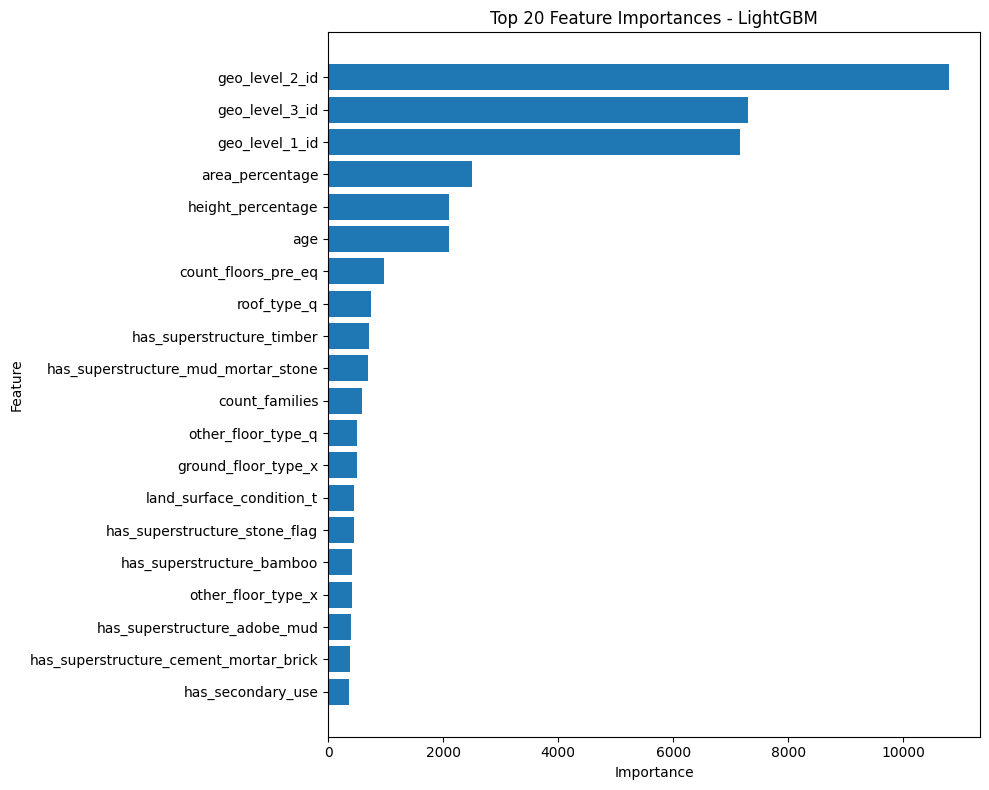

In [ ]:
import matplotlib.pyplot as plt

top_n = 20

top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.title('Top 20 Feature Importances - LightGBM')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

This tells us:

Geography is by far the strongest signal in the dataset.

Which actually makes sense: earthquake intensity varies by location construction practices vary by region, terrain varies by region...

In [ ]:
v4_Final_dataset = pd.read_csv('/content/drive/MyDrive/Datamites_proj_2_EQ/Checkpoints_my/v3_all_category_to_numerical')
v4_Final_dataset.head(15)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u
0,802906,6,487,12198,2,30.0,6,5,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
1,28830,8,900,2812,2,10.0,8,7,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
2,94947,21,363,8973,2,10.0,5,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
3,590882,22,418,10694,2,10.0,6,5,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
4,201944,11,131,1488,3,30.0,8,9,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
5,333020,8,558,6089,2,10.0,9,5,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
6,728451,9,475,12066,2,25.0,3,4,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
7,475515,20,323,12236,2,0.0,8,6,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1
8,441126,0,757,7219,2,15.0,8,6,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
9,989500,26,886,994,1,0.0,13,4,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0


In [ ]:
print(v4_Final_dataset['age'].max())
print(v4_Final_dataset['height_percentage'].max())

print(v4_Final_dataset['area_percentage'].max())

200.0
32
100


**My next checkpoint/experiment would be:**

Does frequency encoding beat raw geo IDs(which was computed early on) in LightGBM?

Because your feature importance plot is practically screaming that geography is the feature family that matters most.

**Frequency encoding on 'geo_level_1_id', geo_level_2_id, geo_level_3_id features**

In [ ]:
geo_cols1 = [
    'geo_level_1_id',
    'geo_level_2_id',
    'geo_level_3_id'
]

for col in geo_cols1:
    freq_map = v4_Final_dataset[col].value_counts() / len(v4_Final_dataset)
    v4_Final_dataset[col] = v4_Final_dataset[col].map(freq_map)

In [ ]:
v4_Final_dataset.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,age_unknown,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u
0,802906,0.093557,0.001036,0.000142,2,30.0,6,5,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
1,28830,0.073215,0.000764,0.000061,2,10.0,8,7,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
2,94947,0.057133,0.006754,0.000522,2,10.0,5,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
3,590882,0.023991,0.000787,0.000119,2,10.0,6,5,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
4,201944,0.031542,0.003983,0.000468,3,30.0,8,9,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0


Create X and y

In [ ]:
X = v4_Final_dataset.drop(columns=['building_id', 'damage_grade'])
y = v4_Final_dataset['damage_grade']

In [ ]:
X.head()

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,age_unknown,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u
0,0.093557,0.001036,0.000142,2,30.0,6,5,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
1,0.073215,0.000764,0.000061,2,10.0,8,7,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
2,0.057133,0.006754,0.000522,2,10.0,5,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
3,0.023991,0.000787,0.000119,2,10.0,6,5,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
4,0.031542,0.003983,0.000468,3,30.0,8,9,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0


**Train-Test Split**

Use the same split settings as before:

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

**Next experiment to increase the performance of model:**

Model Training (LightGBM) + Frequency encoded geo_level_* features(this time)

In [ ]:
from lightgbm import LGBMClassifier

lgbm_freq_model = LGBMClassifier(
    objective='multiclass',
    num_class=3,

    n_estimators=500,
    learning_rate=0.05,

    max_depth=10,
    num_leaves=31,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    n_jobs=-1
)

lgbm_freq_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.082375 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 741
[LightGBM] [Info] Number of data points in the train set: 208480, number of used features: 60
[LightGBM] [Info] Start training from score -2.339173
[LightGBM] [Info] Start training from score -0.564028
[LightGBM] [Info] Start training from score -1.094582


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=10,
               n_estimators=500, n_jobs=-1, num_class=3, objective='multiclass',
               random_state=42, subsample=0.8)

**Model prediction and Evaluation part**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Predictions
y_train_pred = lgbm_freq_model.predict(X_train)
y_test_pred = lgbm_freq_model.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Macro F1
train_macro_f1 = f1_score(
    y_train,
    y_train_pred,
    average='macro'
)

test_macro_f1 = f1_score(
    y_test,
    y_test_pred,
    average='macro'
)

print("Train Accuracy:", round(train_accuracy, 4))
print("Test Accuracy :", round(test_accuracy, 4))

print("\nTrain Macro F1:", round(train_macro_f1, 4))
print("Test Macro F1 :", round(test_macro_f1, 4))

print("\nClassification Report (Test Data):\n")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix (Test Data):\n")
print(confusion_matrix(y_test, y_test_pred))

Train Accuracy: 0.7395
Test Accuracy : 0.7296

Train Macro F1: 0.6839
Test Macro F1 : 0.6677

Classification Report (Test Data):

              precision    recall  f1-score   support

           1       0.69      0.46      0.56      5025
           2       0.72      0.85      0.78     29652
           3       0.75      0.60      0.66     17444

    accuracy                           0.73     52121
   macro avg       0.72      0.64      0.67     52121
weighted avg       0.73      0.73      0.72     52121


Confusion Matrix (Test Data):

[[ 2324  2645    56]
 [  946 25318  3388]
 [   79  6981 10384]]


To investigate the impact of geographical feature representation, frequency encoding was applied to the geo-level identifiers.


However, the resulting model performance showed negligible improvement compared to using the original or raw geo-level identifiers.

This suggests that LightGBM was already capable of extracting useful partitioning information from the raw geographical identifiers, making additional frequency encoding unnecessary for this dataset.

My experiments indicate:

Random Forest           ≈ 0.62 Macro F1
LightGBM + Raw Geo      ≈ 0.664 Macro F1
LightGBM + Freq Geo     ≈ 0.665 Macro F1

Therefore:

The biggest gain came from switching to a boosting model, not from geo encoding.

**My next experiment introduces Cross Validation.**

As usual, preparing X,y seperately, so, it doesnt mix up earlier variables

In [ ]:
X = v4_Final_dataset.drop(columns=['building_id', 'damage_grade'])
y = v4_Final_dataset['damage_grade']

**Cross validation idea, On the LightGBM model:**

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

lgbm_cv_model = LGBMClassifier(
    objective='multiclass',
    num_class=3,

    n_estimators=500,
    learning_rate=0.05,

    max_depth=10,
    num_leaves=31,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    n_jobs=-1
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    lgbm_cv_model,
    X,
    y,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("Fold Scores:")
print(cv_scores)

print("\nMean Macro F1:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Fold Scores:
[0.66541827 0.66643777 0.66529167 0.66793079 0.66192633]

Mean Macro F1: 0.6654009647104125
Std Dev: 0.001977893801130544


**Interpreting the results:**

Performance is stable

Train-test result (~0.665) was representative

Model generalizes consistently

The standard deviation is actually very important. Since, < 0.01 → very stable model



**Conclusion:**

This project developed a machine learning pipeline to predict earthquake damage grades using structural, geographical, and ownership-related building features. Exploratory Data Analysis (EDA) revealed class imbalance, skewed numerical distributions, and the importance of geographical information in damage prediction.

Appropriate preprocessing techniques were applied, including one-hot encoding for categorical variables, logarithmic transformation of skewed numerical features, and experimentation with frequency encoding for geographical identifiers. Multiple models were evaluated, beginning with a Random Forest baseline and subsequently using a LightGBM classifier.

The LightGBM model achieved superior performance compared to the Random Forest model, demonstrating improved classification capability across the three damage grades. Furthermore, 5-fold Stratified Cross Validation produced highly consistent Macro F1 scores with a very low standard deviation ~0.001, indicating strong model stability and reliable generalization.

Feature importance analysis revealed that geographical features contributed significantly to prediction performance, highlighting the influence of regional characteristics on earthquake damage outcomes.

Overall, the proposed approach successfully demonstrates the application of machine learning techniques for earthquake damage assessment and provides a robust baseline for future improvements.


**Challenges Faced**

Several challenges were encountered during the development of this project. One of the primary challenges was handling high-cardinality geographical features such as geo_level_2_id and geo_level_3_id, which contained a large number of unique values.
Determining an appropriate encoding strategy required experimentation with both raw identifiers and frequency encoding techniques.

Another challenge involved selecting suitable preprocessing methods for numerical features. Features such as age and area_percentage exhibited skewed distributions, requiring exploratory analysis and transformation to improve feature representation.

The dataset also exhibited class imbalance across the damage grades, making accuracy an insufficient evaluation metric. To address this, Macro F1 Score was adopted as the primary evaluation metric to ensure balanced assessment across all classes.

Finally, identifying the most effective model required experimentation with multiple algorithms. A Random Forest baseline was first established and subsequently compared with LightGBM, which demonstrated improved performance and more stable generalization across cross-validation folds.


**Future Work:**

Although the developed model achieved stable and reliable performance, several opportunities remain for further improvement. Future work may include:

• Hyperparameter optimization of the LightGBM model using Grid Search or Random Search

• Evaluation of alternative gradient boosting algorithms such as CatBoost and XGBoost.

• Exploration of advanced geographical feature engineering techniques, including target encoding and spatial aggregation methods.

• Investigation of feature selection techniques to identify the most influential predictors and reduce model complexity.

• Development of ensemble approaches combining multiple machine learning models to improve predictive performance.



## THE END

---

